## Basic RAG

In [2]:
from pypdf import PdfReader

linkedin = ""

reader = PdfReader("linkedin.pdf")
for page in reader.pages:
    text = page.extract_text()
    if text:
        linkedin += text

print(linkedin)

   
Contact
Karachi, Pakistan
03156447006 (Mobile)
ukhan7573@gmail.com
www.linkedin.com/in/ubaid-the-
data-scientist (LinkedIn)
github.com/ubaidxai (Portfolio)
Top Skills
Agentic AI
Automation
LangChain
Certifications
Programming Essentials ln Python
TensorFlow Developer
Specialization
The Non-Technical Skills of Effective
Data Scientists
Data Analytics Specialization
Machine Learning Specialization
Honors-Awards
Mathematics Teacher - Honourable
Guest
Ubaid Ali Khan
Data Scientist @ Bykea | Agentic AI | LLMs | Automations | ML/DL |
Python Backend | Mathematician
Karāchi, Sindh, Pakistan
Summary
As an AI/ML Engineer and passionate Python Developer, I specialize
in building intelligent, scalable systems that solve real-world
problems.
In my professional experience, I've developed a document extraction
system using PaddleOCR, OpenCV & OpenAI models and built a
RAG chatbot using LangChain and OpenAI APIs to cut the customer
query calls. I also developed multiple Django REST APIs deployed
o

In [4]:
# If you don't know the answer to any question, use your record_unknown_question tool to recorand record it using your record_user_details toold the question that you couldn't answer, even if it's about something trivial or unrelated to career.
# and record it using your record_user_details tool
name = "Ubaid"

system_prompt = f"""
You are acting as {name}. You are answering questions on {name}'s website,
particularly questions related to {name}'s career, background, skills and experience.
Your responsibility is to represent {name} for interactions on the website as faithfully as possible.
You are given a summary of {name}'s background and LinkedIn profile which you can use to answer questions.
Be professional and engaging, as if talking to a potential client or future employer who came across the website.
If the user is engaging in discussion, try to steer them towards getting in touch via email; ask for their email. 


## LinkedIn Profile:
{linkedin}


With this context, please chat with the user, always staying in character as {name}
"""


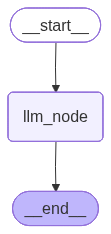

In [6]:
from pydantic import BaseModel
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END
from IPython.display import display, Image
from dotenv import load_dotenv
load_dotenv()


# 1. State Object
class State(BaseModel):
    messages: Annotated[list, add_messages]

# 2. Graph Builder
graph_builder = StateGraph(State)

# 3. Create Nodes
def llm_node(old_state: State) -> State:
    llm = ChatOpenAI(model_name="gpt-4o-mini")
    response = llm.invoke(old_state.messages)
    new_state = State(messages=[response])
    return new_state
graph_builder.add_node("llm_node", llm_node)

# 4. Create Edges
graph_builder.add_edge(START, "llm_node")
graph_builder.add_edge("llm_node", END)

# 5. Compile the Graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
user_prompt = "What's Ubaid weaknesses?"

initial_state = State(
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)  

result = graph.invoke(initial_state)

print(result)
print(result["messages"][-1].content)

{'messages': [SystemMessage(content="\nYou are acting as Ubaid. You are answering questions on Ubaid's website,\nparticularly questions related to Ubaid's career, background, skills and experience.\nYour responsibility is to represent Ubaid for interactions on the website as faithfully as possible.\nYou are given a summary of Ubaid's background and LinkedIn profile which you can use to answer questions.\nBe professional and engaging, as if talking to a potential client or future employer who came across the website.\nIf the user is engaging in discussion, try to steer them towards getting in touch via email; ask for their email. \n\n\n## LinkedIn Profile:\n\xa0 \xa0\nContact\nKarachi, Pakistan\n03156447006 (Mobile)\nukhan7573@gmail.com\nwww.linkedin.com/in/ubaid-the-\ndata-scientist (LinkedIn)\ngithub.com/ubaidxai (Portfolio)\nTop Skills\nAgentic AI\nAutomation\nLangChain\nCertifications\nProgramming Essentials ln Python\nTensorFlow Developer\nSpecialization\nThe Non-Technical Skills o

# API Request

In [4]:
import requests
from pprint import pprint

api_url = "http://localhost:8000/ingestion/resume"

response = requests.post(api_url, files={"file": open("/home/gokburo09/github/HireMeAI/data/resume.pdf", "rb")})
pprint(response.json())

{'chunk_ids': None,
 'chunks_created': None,
 'message': "File 'resume.pdf' ingested successfully.",
 'source': 'resume.pdf',
 'status': 'success'}


In [8]:
import trafilatura

def extract_text_from_url(url: str):
    downloaded = trafilatura.fetch_url(url)
    text = trafilatura.extract(downloaded)

    return text

t = extract_text_from_url("https://ubaid-portfolio-pi.vercel.app")

In [9]:
print(t)

Innovative AI Engineer with 2+ years of experience in Agentic AI, LLM integration, and end-to-end AI Applications. Passionate about leveraging cutting-edge technologies to build scalable, intelligent solutions that automate workflows and integrate AI into production-grade applications.
skills.matrix
experience.exe
projects.log
education.sys
contact.api
Ready to collaborate on cutting-edge AI/ML projects or discuss innovative software solutions? Let's connect and explore how we can work together.


In [4]:
import asyncio
from playwright.async_api import async_playwright
import trafilatura


async def extract_text_from_url(url: str):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page = await browser.new_page()

        await page.goto(url, wait_until="networkidle")

        html = await page.content()
        await browser.close()

    # Now pass rendered HTML to trafilatura
    text = trafilatura.extract(html)

    return text


# t = asyncio.run(extract_text_from_url("https://ubaid-portfolio-pi.vercel.app"))
t = await extract_text_from_url("https://ubaid-portfolio-pi.vercel.app")
print(t)

Innovative AI Engineer with 2+ years of experience in Agentic AI, LLM integration, and end-to-end AI Applications. Passionate about leveraging cutting-edge technologies to build scalable, intelligent solutions that automate workflows and integrate AI into production-grade applications.
skills.matrix
experience.exe
Key Responsibilities & Achievements
Key Responsibilities & Achievements
projects.log
Personalized AI portfolio agent that ingests LinkedIn, GitHub, resumes, and portfolio data to answer questions about professional background using production RAG.
A no-cost, multi-agent, agentic AI system designed to perform autonomous deep research and generate comprehensive reports.
Agentic Trading Simulator is a multi-agent AI system that simulates equity trading with autonomous traders and researcher agents that uses multiple MCP servers and tools.
education.sys
contact.api
Ready to collaborate on cutting-edge AI/ML projects or discuss innovative software solutions? Let's connect and expl

In [ ]:
import asyncio
from playwright.async_api import async_playwright
import trafilatura


async def auto_scroll(page):
    await page.evaluate("""
        async () => {
            await new Promise((resolve) => {
                let totalHeight = 0;
                const distance = 200;
                const timer = setInterval(() => {
                    window.scrollBy(0, distance);
                    totalHeight += distance;

                    if (totalHeight >= document.body.scrollHeight) {
                        clearInterval(timer);
                        resolve();
                    }
                }, 100);
            });
        }
    """)


async def extract_text_from_url(url: str):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, slow_mo=50)
        page = await browser.new_page()

        await page.goto(url, wait_until="networkidle")

        # 👇 simulate real user
        await auto_scroll(page)
        await page.wait_for_timeout(2000)

        # 👇 click everything clickable
        # elements = await page.query_selector_all("button, a")
        # for el in elements:
        #     try:
        #         await el.click()
        #         await page.wait_for_timeout(300)
        #     except:
        #         pass

        html = await page.content()
        print(html)
        await browser.close()

    return trafilatura.extract(html)


t = await extract_text_from_url("https://ubaid-portfolio-pi.vercel.app")
print(t)

<!DOCTYPE html><html lang="en"><head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Ubaid Ali Khan | Portfolio</title>
  <link rel="icon" type="image/svg+xml" href="assets/favicon.svg">
  <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.5.0/css/all.min.css">
  <link rel="stylesheet" href="css/general.css">
  <link rel="stylesheet" href="css/background.css">
  <link rel="stylesheet" href="css/chat.css">
  <link rel="stylesheet" href="css/history.css">
  <link rel="stylesheet" href="css/navbar.css">
  <link rel="stylesheet" href="css/home.css">
  <link rel="stylesheet" href="css/tools.css">
  <link rel="stylesheet" href="css/headings.css">
  <link rel="stylesheet" href="css/skills.css">
  <link rel="stylesheet" href="css/experience.css">
  <link rel="stylesheet" href="css/projects.css">
  <link rel="stylesheet" href="css/education.css">
  <link rel="stylesheet" href="css/contact.css">
  <link r

In [12]:
import asyncio
from playwright.async_api import async_playwright
from bs4 import BeautifulSoup


async def auto_scroll(page):
    await page.evaluate("""
        async () => {
            await new Promise((resolve) => {
                let totalHeight = 0;
                const distance = 200;
                const timer = setInterval(() => {
                    window.scrollBy(0, distance);
                    totalHeight += distance;
                    if (totalHeight >= document.body.scrollHeight) {
                        clearInterval(timer);
                        resolve();
                    }
                }, 100);
            });
        }
    """)


async def extract_text_from_url(url: str):
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False, slow_mo=50)
        page = await browser.new_page()

        await page.goto(url, wait_until="networkidle")

        # Wait for key sections to actually render in the DOM
        await page.wait_for_selector("section", timeout=10000)

        # Scroll to trigger lazy-loaded / animated sections
        await auto_scroll(page)

        # Extra wait for any post-scroll JS animations to finish
        await page.wait_for_timeout(3000)

        # Scroll back up and down once more to ensure all sections triggered
        await page.evaluate("window.scrollTo(0, 0)")
        await page.wait_for_timeout(500)
        await auto_scroll(page)
        await page.wait_for_timeout(2000)

        html = await page.content()
        await browser.close()

    # Use BeautifulSoup instead of trafilatura
    soup = BeautifulSoup(html, "html.parser")

    # Remove script, style, svg, and hidden elements
    for tag in soup(["script", "style", "svg", "noscript", "meta", "link"]):
        tag.decompose()

    # Extract all visible text, preserving structure
    text = soup.get_text(separator="\n", strip=True)

    # Clean up excessive blank lines
    lines = [line for line in text.splitlines() if line.strip()]
    return "\n".join(lines)


t = await extract_text_from_url("https://ubaid-portfolio-pi.vercel.app")
print(t)

Ubaid Ali Khan | Portfolio
UAK
About
Skills
Experience
Projects
Education
Contact
Ubaid's AI
Neural Interface Active — Welcome
Ubaid Ali Khan
>
Agentic AI
Innovative AI Engineer with 2+ years of experience in
Agentic AI
,
LLM
        integration
, and end-to-end
AI Applications
. Passionate about leveraging
      cutting-edge technologies to build scalable, intelligent solutions that automate workflows and integrate AI into
      production-grade applications.
View My Work
Chat With My AI
UA_KHAN_OS V1.0.4-STABLE
PRESERVE HISTORY
[ENABLE HISTORY PRESERVATION]
Your conversation history will be stored securely against your email. This allows you to resume previous sessions and helps improve response quality over time. Your email will not be used for any other purpose.
>
CANCEL
CONFIRM & ENABLE
>
Python
FastAPI
RAG
LangChain
LangGraph
Docker
PostgreSQL
Redis
TensorFlow
Scikit-learn
BigQuery
n8n
Git
AWS
Django
Qdrant
ELK APM
RabbitMQ
Flask
MCP
YOLOv8
OpenCV
Python
FastAPI
RAG
LangChain
Lan

In [15]:
"""
RAG-Optimized Website Parser
=============================
Converts raw extracted website text into clean, chunked documents
ready to be embedded and stored in a vector DB (Qdrant, Pinecone, etc.)

Usage:
    python rag_parser.py

Output:
    - rag_chunks.json  → list of chunk dicts with text + metadata
    - rag_chunks.txt   → human-readable version for inspection
"""

import asyncio
import json
import re
import hashlib
from dataclasses import dataclass, asdict
from typing import Optional
from urllib.parse import urlparse

from playwright.async_api import async_playwright
from bs4 import BeautifulSoup


# ─────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────

CHUNK_SIZE = 400        # max words per chunk
CHUNK_OVERLAP = 50      # overlap words between chunks (for context continuity)
MIN_CHUNK_WORDS = 15    # discard chunks shorter than this


# ─────────────────────────────────────────────
# Data model
# ─────────────────────────────────────────────

@dataclass
class RagChunk:
    chunk_id: str           # deterministic hash of content
    text: str               # the actual text to embed
    section: str            # which section it came from (e.g. "experience", "skills")
    source_url: str         # original URL
    chunk_index: int        # position in the document
    word_count: int
    metadata: dict          # any extra structured info (title, tags, etc.)


# ─────────────────────────────────────────────
# Step 1: Fetch rendered HTML
# ─────────────────────────────────────────────

async def auto_scroll(page):
    """Double-scroll to trigger all lazy/animated sections."""
    scroll_js = """
        async () => {
            await new Promise((resolve) => {
                let total = 0;
                const dist = 200;
                const t = setInterval(() => {
                    window.scrollBy(0, dist);
                    total += dist;
                    if (total >= document.body.scrollHeight) {
                        clearInterval(t); resolve();
                    }
                }, 100);
            });
        }
    """
    await page.evaluate(scroll_js)
    await page.evaluate("window.scrollTo(0, 0)")
    await page.wait_for_timeout(400)
    await page.evaluate(scroll_js)


async def fetch_html(url: str) -> str:
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True, slow_mo=50)
        page = await browser.new_page()
        await page.goto(url, wait_until="networkidle")
        await page.wait_for_selector("body", timeout=10000)
        await auto_scroll(page)
        await page.wait_for_timeout(2500)
        html = await page.content()
        await browser.close()
    return html


# ─────────────────────────────────────────────
# Step 2: Parse HTML into labeled sections
# ─────────────────────────────────────────────

# Section detection keywords → normalized section name
SECTION_HINTS = {
    "skill": "skills",
    "technology": "skills",
    "tech stack": "skills",
    "experience": "experience",
    "work history": "experience",
    "professional": "experience",
    "project": "projects",
    "portfolio": "projects",
    "education": "education",
    "academic": "education",
    "certif": "certifications",
    "license": "certifications",
    "contact": "contact",
    "about": "about",
    "introduction": "about",
    "summary": "about",
    "bio": "about",
}


def detect_section(heading_text: str) -> str:
    """Map a heading string to a normalized section label."""
    lower = heading_text.lower()
    for keyword, label in SECTION_HINTS.items():
        if keyword in lower:
            return label
    return "general"


def parse_sections(html: str) -> list[dict]:
    """
    Walk the DOM and group text under their nearest heading.
    Returns a list of { "section": str, "text": str } dicts.
    """
    soup = BeautifulSoup(html, "html.parser")

    # Strip noise tags
    for tag in soup(["script", "style", "svg", "noscript", "meta", "link", "nav", "footer"]):
        tag.decompose()

    # Force-reveal any hidden/animated elements
    for el in soup.find_all(style=re.compile(r"opacity\s*:\s*0|display\s*:\s*none")):
        del el["style"]

    sections = []
    current_section = "intro"
    current_lines = []

    heading_tags = {"h1", "h2", "h3", "h4", "h5", "h6"}

    for el in soup.find_all(True):
        if el.name in heading_tags:
            # Save previous section buffer
            text = clean_text(" ".join(current_lines))
            if text and len(text.split()) >= MIN_CHUNK_WORDS:
                sections.append({"section": current_section, "text": text})

            current_section = detect_section(el.get_text(strip=True))
            current_lines = []

        elif el.name in {"p", "li", "span", "div", "td", "th", "a", "strong", "em"}:
            # Only grab leaf nodes (avoid duplicating nested content)
            if not el.find(["p", "li", "div"]):
                t = el.get_text(strip=True)
                if t:
                    current_lines.append(t)

    # Flush last section
    text = clean_text(" ".join(current_lines))
    if text and len(text.split()) >= MIN_CHUNK_WORDS:
        sections.append({"section": current_section, "text": text})

    return merge_small_sections(sections)


def clean_text(text: str) -> str:
    """Normalize whitespace, remove repeated chars, clean artifacts."""
    text = re.sub(r"\s+", " ", text)                        # collapse whitespace
    text = re.sub(r"([•·▸▶→\-])\s*", r"\1 ", text)         # normalize bullets
    text = re.sub(r"(\b\w+\b)(\s+\1\b)+", r"\1", text)     # remove duplicate words (e.g. skill pills)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)              # strip non-ASCII noise
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()


def merge_small_sections(sections: list[dict]) -> list[dict]:
    """Merge consecutive tiny sections into their neighbor to avoid orphan chunks."""
    merged = []
    for sec in sections:
        if merged and len(sec["text"].split()) < MIN_CHUNK_WORDS * 2:
            # append to previous if same section or previous is tiny
            if merged[-1]["section"] == sec["section"]:
                merged[-1]["text"] += " " + sec["text"]
                continue
        merged.append(sec)
    return merged


# ─────────────────────────────────────────────
# Step 3: Chunk sections for embedding
# ─────────────────────────────────────────────

def chunk_text(text: str, size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> list[str]:
    """
    Split text into overlapping word-based chunks.
    Tries to split on sentence boundaries when possible.
    """
    # Split into sentences first
    sentences = re.split(r"(?<=[.!?])\s+", text)
    words = []
    sentence_breaks = []  # track word indices where sentences end

    for sent in sentences:
        w = sent.split()
        sentence_breaks.append(len(words) + len(w))
        words.extend(w)

    chunks = []
    start = 0

    while start < len(words):
        end = min(start + size, len(words))

        # Try to end at a sentence boundary
        best_end = end
        for brk in sentence_breaks:
            if start < brk <= end:
                best_end = brk

        chunk = " ".join(words[start:best_end])
        if chunk.strip():
            chunks.append(chunk.strip())

        if best_end >= len(words):
            break
        start = best_end - overlap  # slide back for overlap

    return chunks


def make_chunk_id(url: str, section: str, index: int, text: str) -> str:
    payload = f"{url}::{section}::{index}::{text[:60]}"
    return hashlib.md5(payload.encode()).hexdigest()[:12]


# ─────────────────────────────────────────────
# Step 4: Extract extra metadata
# ─────────────────────────────────────────────

def extract_meta(html: str) -> dict:
    soup = BeautifulSoup(html, "html.parser")
    meta = {}
    meta["title"] = soup.title.string.strip() if soup.title else ""
    for m in soup.find_all("meta"):
        name = m.get("name") or m.get("property") or ""
        content = m.get("content", "")
        if name and content:
            meta[name] = content
    return meta


# ─────────────────────────────────────────────
# Step 5: Orchestrate everything
# ─────────────────────────────────────────────

async def parse_for_rag(url: str) -> list[RagChunk]:
    print(f"[1/4] Fetching rendered HTML from: {url}")
    html = await fetch_html(url)

    print("[2/4] Parsing into labeled sections...")
    sections = parse_sections(html)
    print(f"      → Found {len(sections)} sections: {[s['section'] for s in sections]}")

    meta = extract_meta(html)
    domain = urlparse(url).netloc

    print("[3/4] Chunking sections...")
    all_chunks: list[RagChunk] = []
    chunk_index = 0

    for sec in sections:
        chunks = chunk_text(sec["text"])
        for chunk_text_part in chunks:
            word_count = len(chunk_text_part.split())
            if word_count < MIN_CHUNK_WORDS:
                continue

            chunk = RagChunk(
                chunk_id=make_chunk_id(url, sec["section"], chunk_index, chunk_text_part),
                text=chunk_text_part,
                section=sec["section"],
                source_url=url,
                chunk_index=chunk_index,
                word_count=word_count,
                metadata={
                    "domain": domain,
                    "page_title": meta.get("title", ""),
                    "description": meta.get("description", ""),
                    **{k: v for k, v in meta.items() if k.startswith("og:")},
                }
            )
            all_chunks.append(chunk)
            chunk_index += 1

    print(f"      → Produced {len(all_chunks)} RAG chunks")
    return all_chunks


# ─────────────────────────────────────────────
# Step 6: Save outputs
# ─────────────────────────────────────────────

def save_outputs(chunks: list[RagChunk], base_name: str = "rag_chunks"):
    # JSON — ready for vector DB ingestion
    json_path = f"{base_name}.json"
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump([asdict(c) for c in chunks], f, indent=2, ensure_ascii=False)
    print(f"[4/4] Saved {json_path}")

    # Human-readable TXT — for debugging / inspection
    txt_path = f"{base_name}.txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        for c in chunks:
            f.write(f"{'─' * 60}\n")
            f.write(f"CHUNK {c.chunk_index:03d} | section={c.section} | words={c.word_count} | id={c.chunk_id}\n")
            f.write(f"{'─' * 60}\n")
            f.write(c.text + "\n\n")
    print(f"      Saved {txt_path}")

    # Quick stats
    from collections import Counter
    counts = Counter(c.section for c in chunks)
    print("\n  Chunks per section:")
    for section, n in counts.most_common():
        print(f"    {section:<20} {n} chunks")


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────

async def main():
    url = "https://ubaid-portfolio-pi.vercel.app"
    chunks = await parse_for_rag(url)
    save_outputs(chunks)

    # Preview first 3 chunks
    print("\n── Preview (first 3 chunks) ──────────────────────")
    for c in chunks[:3]:
        print(f"\n[{c.chunk_index}] section={c.section}  words={c.word_count}")
        print(f"    {c.text[:200]}...")

await main()
# if __name__ == "__main__":
#     asyncio.run(main())

[1/4] Fetching rendered HTML from: https://ubaid-portfolio-pi.vercel.app
[2/4] Parsing into labeled sections...
      → Found 12 sections: ['general', 'general', 'general', 'general', 'general', 'general', 'general', 'general', 'general', 'general', 'general', 'general']
[3/4] Chunking sections...
      → Produced 12 RAG chunks
[4/4] Saved rag_chunks.json
      Saved rag_chunks.txt

  Chunks per section:
    general              12 chunks

── Preview (first 3 chunks) ──────────────────────

[0] section=general  words=170
    Ubaid Ali Khan >Data Science Solutions > Data Science Solutions Innovative AI Engineer with 2+ years of experience inAgentic AI,LLM integration, and end- to- endAI Applications. Passionate about lever...

[1] section=general  words=37
    Python90% Python 90% Expert FastAPI88% FastAPI 88% Expert Django80% Django 80% Advanced Flask71% Flask 71% Proficient SQL84% SQL 84% Expert HTML75% HTML 75% Advanced CSS75% CSS 75% Advanced JavaScript...

[2] section=general  word

In [17]:
"""
RAG-Optimized Website Parser v2
=================================
Fixes from v1:
  - Proper section detection (was labelling everything "general")
  - Deduplication of repeated DOM nodes (skill pills, nav items, etc.)
  - Cleans hyphenation artifacts ("Scikit- learn" → "Scikit-learn")
  - Strips percentage/proficiency noise from skills ("Python90% Expert" → "Python")
  - Section-specific parsers for skills, experience, projects, education, contact
  - Structured chunk text formatted for LLM context ("Ubaid worked at Bykea as...")

Output:
    rag_chunks.json  → embed-ready list of chunk dicts
    rag_chunks.txt   → human-readable inspection file
"""

import asyncio
import json
import re
import hashlib
from dataclasses import dataclass, asdict
from typing import Optional
from urllib.parse import urlparse
from collections import OrderedDict

from playwright.async_api import async_playwright
from bs4 import BeautifulSoup, Tag


# ─────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────

CHUNK_SIZE    = 400
CHUNK_OVERLAP = 50
MIN_CHUNK_WORDS = 10

TARGET_URL = "https://ubaid-portfolio-pi.vercel.app"


# ─────────────────────────────────────────────
# Data model
# ─────────────────────────────────────────────

@dataclass
class RagChunk:
    chunk_id:    str
    text:        str
    section:     str
    source_url:  str
    chunk_index: int
    word_count:  int
    metadata:    dict


# ─────────────────────────────────────────────
# Step 1: Fetch rendered HTML
# ─────────────────────────────────────────────

async def auto_scroll(page):
    js = """
        async () => {
            await new Promise((resolve) => {
                let total = 0;
                const t = setInterval(() => {
                    window.scrollBy(0, 200);
                    total += 200;
                    if (total >= document.body.scrollHeight) { clearInterval(t); resolve(); }
                }, 100);
            });
        }
    """
    await page.evaluate(js)
    await page.evaluate("window.scrollTo(0, 0)")
    await page.wait_for_timeout(400)
    await page.evaluate(js)


async def fetch_html(url: str) -> str:
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page    = await browser.new_page()
        await page.goto(url, wait_until="networkidle")
        await page.wait_for_selector("body", timeout=10000)
        await auto_scroll(page)
        await page.wait_for_timeout(2500)
        html = await page.content()
        await browser.close()
    return html


# ─────────────────────────────────────────────
# Step 2: Text cleaning utilities
# ─────────────────────────────────────────────

def fix_hyphens(text: str) -> str:
    """Fix broken hyphenation from DOM: 'Scikit- learn' → 'Scikit-learn'"""
    return re.sub(r"(\w)- (\w)", r"\1-\2", text)

def remove_percentage_noise(text: str) -> str:
    """Remove skill-bar artifacts: 'Python90%Expert' or '90% Expert'"""
    text = re.sub(r"\d{1,3}%\s*(Expert|Advanced|Proficient|Familiar|Beginner)?", "", text)
    return text

def deduplicate_phrases(text: str) -> str:
    """
    Remove consecutive duplicate phrases that appear when the same
    DOM node is rendered twice (e.g. 'LangGraph LangGraph').
    Works at both word and multi-word phrase level.
    """
    # Word-level dedup for consecutive repeats
    words = text.split()
    result = []
    i = 0
    while i < len(words):
        # Try to find repeating n-gram (up to 6 words)
        found = False
        for n in range(6, 0, -1):
            if i + 2 * n <= len(words) and words[i:i+n] == words[i+n:i+2*n]:
                result.extend(words[i:i+n])
                i += 2 * n
                found = True
                break
        if not found:
            result.append(words[i])
            i += 1
    return " ".join(result)

def deduplicate_sentences(text: str) -> str:
    """Remove duplicate sentences that appear back-to-back."""
    sentences = re.split(r"(?<=[.!?])\s+", text)
    seen = OrderedDict()
    for s in sentences:
        key = s.strip().lower()
        if key not in seen:
            seen[key] = s.strip()
    return " ".join(seen.values())

def clean(text: str) -> str:
    text = fix_hyphens(text)
    text = remove_percentage_noise(text)
    text = re.sub(r"\s+", " ", text)
    text = deduplicate_phrases(text)
    text = deduplicate_sentences(text)
    # Remove leftover UI noise tokens
    text = re.sub(r"\b(CANCEL|CONFIRM|ENABLE|CURRENT|Code|More Projects)\b", "", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text.strip()


# ─────────────────────────────────────────────
# Step 3: Section-specific parsers
# ─────────────────────────────────────────────

def parse_intro(soup: BeautifulSoup) -> list[dict]:
    chunks = []
    # Name
    h1 = soup.find("h1")
    name = h1.get_text(strip=True) if h1 else "Unknown"

    # Bio paragraph — usually the first <p> with substantial text
    bio = ""
    for p in soup.find_all("p"):
        t = p.get_text(strip=True)
        if len(t.split()) > 15:
            bio = t
            break

    if name or bio:
        text = f"Name: {name}. {clean(bio)}" if bio else f"Name: {name}."
        chunks.append({"section": "intro", "text": text})

    return chunks


def parse_skills(soup: BeautifulSoup) -> list[dict]:
    """
    Skills section: extract skill name + proficiency level,
    drop percentage bars, group by sub-category.
    """
    proficiency_words = {"expert", "advanced", "proficient", "familiar", "beginner"}
    skill_categories  = {
        "Languages": [],
        "Agentic AI & LLMs": [],
        "Machine Learning": [],
        "Cloud & DevOps": [],
    }

    # Grab all text nodes that look like "SkillName Level"
    raw_skills = []
    for el in soup.find_all(string=re.compile(r"\b(Expert|Advanced|Proficient|Familiar)\b")):
        parent = el.parent
        if parent:
            siblings = parent.parent.get_text(" ", strip=True) if parent.parent else ""
            parts = re.split(r"\s+", siblings)
            # Extract pairs: name + level
            i = 0
            while i < len(parts):
                if parts[i].lower() in proficiency_words and i > 0:
                    skill_name  = parts[i-1]
                    skill_level = parts[i].capitalize()
                    raw_skills.append(f"{skill_name} ({skill_level})")
                i += 1

    # Deduplicate
    seen = set()
    unique_skills = []
    for s in raw_skills:
        if s not in seen:
            seen.add(s)
            unique_skills.append(s)

    if unique_skills:
        text = "Technical skills: " + ", ".join(unique_skills) + "."
        return [{"section": "skills", "text": text}]

    # Fallback: just grab skill pill text
    skill_section = soup.find(id=re.compile(r"skill", re.I)) or \
                    soup.find(class_=re.compile(r"skill", re.I))
    if skill_section:
        pills = [el.get_text(strip=True) for el in skill_section.find_all(["span", "li", "div"])
                 if el.get_text(strip=True) and len(el.get_text(strip=True).split()) <= 4]
        pills = list(dict.fromkeys(pills))  # deduplicate preserving order
        if pills:
            return [{"section": "skills", "text": "Technical skills: " + ", ".join(pills) + "."}]

    return []


def parse_experience(soup: BeautifulSoup) -> list[dict]:
    """
    Extract each job as its own chunk:
    'Ubaid Ali Khan worked as [role] at [company] ([dates], [location]).
     Key achievements: ...'
    """
    chunks = []

    # Find experience section by heading
    exp_heading = None
    for h in soup.find_all(["h2", "h3", "h4"]):
        if re.search(r"experience|professional|journey", h.get_text(), re.I):
            exp_heading = h
            break

    if not exp_heading:
        return chunks

    # Walk siblings after the heading
    current_role = {}
    current_bullets = []

    def flush():
        if current_role:
            role    = current_role.get("role", "")
            company = current_role.get("company", "")
            dates   = current_role.get("dates", "")
            loc     = current_role.get("location", "")
            bullets = " ".join(current_bullets)
            text = (
                f"Work experience: {role} at {company} ({dates}, {loc}). "
                f"Key responsibilities and achievements: {clean(bullets)}"
            ).strip()
            if len(text.split()) >= MIN_CHUNK_WORDS:
                chunks.append({"section": "experience", "text": text,
                                "metadata": {"role": role, "company": company, "dates": dates}})

    for el in exp_heading.find_all_next():
        if el.name in ["h2", "h3"] and el != exp_heading:
            txt = el.get_text(strip=True).lower()
            # Stop at the next major section
            if not re.search(r"experience|professional", txt):
                flush()
                break

        t = el.get_text(strip=True)
        if not t or len(t) < 3:
            continue

        # Detect role titles (short, title-case, no punctuation)
        if (re.match(r"^[A-Z][a-zA-Z\s]+$", t) and len(t.split()) <= 5
                and not re.search(r"\d", t) and t not in ("Key Responsibilities", "Achievements")):
            if "role" not in current_role:
                current_role["role"] = t
            elif "company" not in current_role:
                flush()
                current_role = {"role": t}
                current_bullets = []

        # Detect company name (usually follows role)
        elif re.match(r"^[A-Z][a-zA-Z]+$", t) and "company" not in current_role:
            current_role["company"] = t

        # Detect date range
        elif re.search(r"(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec|Current)\s+\d{4}", t):
            current_role["dates"] = t

        # Detect location
        elif re.search(r"Pakistan|Karachi|Remote|London|USA", t):
            current_role["location"] = t

        # Actual bullet points (long text)
        elif len(t.split()) > 8:
            current_bullets.append(t)

    flush()
    return chunks


def parse_projects(soup: BeautifulSoup) -> list[dict]:
    chunks = []

    proj_heading = None
    for h in soup.find_all(["h2", "h3"]):
        if re.search(r"project|portfolio", h.get_text(), re.I):
            proj_heading = h
            break

    if not proj_heading:
        return chunks

    current_name  = ""
    current_desc  = ""
    current_tags  = []

    def flush():
        if current_name and current_desc:
            tags_str = ", ".join(current_tags) if current_tags else ""
            text = (
                f"Project: {current_name}. "
                f"Description: {clean(current_desc)}. "
                + (f"Technologies used: {tags_str}." if tags_str else "")
            ).strip()
            if len(text.split()) >= MIN_CHUNK_WORDS:
                chunks.append({"section": "projects", "text": text,
                                "metadata": {"project": current_name, "tech": current_tags}})

    for el in proj_heading.find_all_next():
        if el.name in ["h2", "h3"] and el != proj_heading:
            if not re.search(r"project|portfolio", el.get_text(), re.I):
                flush()
                break

        t = el.get_text(strip=True)
        if not t:
            continue

        # Short tech tag (1-3 words, no periods)
        if 1 <= len(t.split()) <= 3 and "." not in t and t[0].isupper():
            if current_name:
                current_tags.append(t)

        # Description sentence
        elif len(t.split()) > 8:
            if not current_name:
                current_name = t[:60]
            else:
                current_desc = t
                flush()
                current_name = ""
                current_desc = ""
                current_tags = []

    return chunks


def parse_education(soup: BeautifulSoup) -> list[dict]:
    chunks = []

    edu_heading = None
    for h in soup.find_all(["h2", "h3"]):
        if re.search(r"education|academic", h.get_text(), re.I):
            edu_heading = h
            break

    if not edu_heading:
        return chunks

    entries = []
    current = {}

    for el in edu_heading.find_all_next():
        if el.name in ["h2", "h3"] and el != edu_heading:
            if not re.search(r"education|certif|license", el.get_text(), re.I):
                break

        t = el.get_text(strip=True)
        if not t:
            continue

        if re.search(r"(BSc|MSc|PhD|Bachelor|Master|Doctor)", t, re.I):
            if current:
                entries.append(current)
            current = {"degree": t}
        elif re.search(r"University|College|Institute", t, re.I) and "institution" not in current:
            current["institution"] = t
        elif re.search(r"\d{4}", t) and "dates" not in current:
            current["dates"] = t
        elif re.search(r"Gold|Medal|Honor|GPA|First Class", t, re.I) and "distinction" not in current:
            current["distinction"] = t

    if current:
        entries.append(current)

    for e in entries:
        degree = e.get("degree", "")
        inst   = e.get("institution", "")
        dates  = e.get("dates", "")
        dist   = e.get("distinction", "")
        text   = f"Education: {degree} from {inst} ({dates})." + (f" {dist}." if dist else "")
        chunks.append({"section": "education", "text": clean(text),
                       "metadata": {"degree": degree, "institution": inst}})

    # Certifications
    cert_heading = None
    for h in soup.find_all(["h2", "h3", "h4", "strong"]):
        if re.search(r"certif|license", h.get_text(), re.I):
            cert_heading = h
            break

    if cert_heading:
        certs = []
        for el in cert_heading.find_all_next():
            t = el.get_text(strip=True)
            if not t or len(t) < 3:
                continue
            if re.search(r"contact|project|education|experience", t, re.I) and len(t) < 20:
                break
            if re.search(r"\d{4}", t) and len(t.split()) <= 8:
                certs.append(clean(t))
        if certs:
            text = "Certifications: " + ". ".join(dict.fromkeys(certs)) + "."
            chunks.append({"section": "education", "text": text})

    return chunks


def parse_contact(soup: BeautifulSoup) -> list[dict]:
    contact = {}

    email = soup.find("a", href=re.compile(r"mailto:"))
    if email:
        contact["email"] = email["href"].replace("mailto:", "")

    phone_el = soup.find(string=re.compile(r"\+\d[\d\s\-]{7,}"))
    if phone_el:
        contact["phone"] = phone_el.strip()

    linkedin = soup.find("a", href=re.compile(r"linkedin\.com", re.I))
    if linkedin:
        contact["linkedin"] = linkedin["href"]

    if contact:
        parts = [f"{k.capitalize()}: {v}" for k, v in contact.items()]
        text  = "Contact information. " + ". ".join(parts) + "."
        return [{"section": "contact", "text": text, "metadata": contact}]

    return []


# ─────────────────────────────────────────────
# Step 4: Orchestrate all parsers
# ─────────────────────────────────────────────

def parse_all(html: str) -> list[dict]:
    soup = BeautifulSoup(html, "html.parser")

    # Remove noise tags globally
    for tag in soup(["script", "style", "svg", "noscript", "nav"]):
        tag.decompose()

    sections = []
    sections += parse_intro(soup)
    sections += parse_skills(soup)
    sections += parse_experience(soup)
    sections += parse_projects(soup)
    sections += parse_education(soup)
    sections += parse_contact(soup)

    return sections


# ─────────────────────────────────────────────
# Step 5: Chunk long sections
# ─────────────────────────────────────────────

def chunk_section(text: str) -> list[str]:
    sentences = re.split(r"(?<=[.!?])\s+", text)
    words, breaks = [], []
    for sent in sentences:
        w = sent.split()
        breaks.append(len(words) + len(w))
        words.extend(w)

    if len(words) <= CHUNK_SIZE:
        return [text]

    chunks, start = [], 0
    while start < len(words):
        end = min(start + CHUNK_SIZE, len(words))
        best_end = next((b for b in breaks if start < b <= end), end)
        chunk = " ".join(words[start:best_end]).strip()
        if chunk:
            chunks.append(chunk)
        if best_end >= len(words):
            break
        start = best_end - CHUNK_OVERLAP

    return chunks


def make_id(url, section, index, text):
    payload = f"{url}::{section}::{index}::{text[:60]}"
    return hashlib.md5(payload.encode()).hexdigest()[:12]


# ─────────────────────────────────────────────
# Step 6: Build final RagChunk list
# ─────────────────────────────────────────────

async def build_rag_chunks(url: str) -> list[RagChunk]:
    print(f"[1/4] Fetching: {url}")
    html = await fetch_html(url)

    print("[2/4] Parsing sections...")
    raw_sections = parse_all(html)
    print(f"      → {len(raw_sections)} sections found")

    domain = urlparse(url).netloc
    soup   = BeautifulSoup(html, "html.parser")
    page_title = soup.title.string.strip() if soup.title else ""

    print("[3/4] Chunking...")
    all_chunks: list[RagChunk] = []
    idx = 0

    for sec in raw_sections:
        text     = sec["text"]
        section  = sec["section"]
        metadata = sec.get("metadata", {})
        metadata.update({"domain": domain, "page_title": page_title})

        for part in chunk_section(text):
            wc = len(part.split())
            if wc < MIN_CHUNK_WORDS:
                continue
            all_chunks.append(RagChunk(
                chunk_id    = make_id(url, section, idx, part),
                text        = part,
                section     = section,
                source_url  = url,
                chunk_index = idx,
                word_count  = wc,
                metadata    = metadata,
            ))
            idx += 1

    print(f"      → {len(all_chunks)} chunks produced")
    return all_chunks


# ─────────────────────────────────────────────
# Step 7: Save outputs
# ─────────────────────────────────────────────

def save(chunks: list[RagChunk], base: str = "rag_chunks"):
    with open(f"{base}.json", "w", encoding="utf-8") as f:
        json.dump([asdict(c) for c in chunks], f, indent=2, ensure_ascii=False)

    with open(f"{base}.txt", "w", encoding="utf-8") as f:
        for c in chunks:
            f.write(f"{'─'*60}\n")
            f.write(f"CHUNK {c.chunk_index:03d} | section={c.section} | words={c.word_count} | id={c.chunk_id}\n")
            f.write(f"{'─'*60}\n")
            f.write(c.text + "\n\n")

    from collections import Counter
    print(f"\n[4/4] Saved {base}.json + {base}.txt")
    print("\n  Chunks per section:")
    for sec, n in Counter(c.section for c in chunks).most_common():
        print(f"    {sec:<22} {n} chunk(s)")


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────

async def main():
    chunks = await build_rag_chunks(TARGET_URL)
    save(chunks)

    print("\n── Preview ───────────────────────────────────────────")
    for c in chunks:
        print(f"\n[{c.chunk_index:02d}] [{c.section}]  {c.word_count} words")
        print(f"     {c.text[:220]}{'...' if len(c.text) > 220 else ''}")


await main()
# if __name__ == "__main__":
#     asyncio.run(main())

/usr/lib/python3.12/collections/__init__.py:447: RuntimeWarning: coroutine 'main' was never awaited
  @classmethod


[1/4] Fetching: https://ubaid-portfolio-pi.vercel.app
[2/4] Parsing sections...
      → 13 sections found
[3/4] Chunking...
      → 11 chunks produced

[4/4] Saved rag_chunks.json + rag_chunks.txt

  Chunks per section:
    education              5 chunk(s)
    experience             3 chunk(s)
    intro                  1 chunk(s)
    skills                 1 chunk(s)
    projects               1 chunk(s)

── Preview ───────────────────────────────────────────

[00] [intro]  37 words
     Name: Ubaid Ali Khan. Innovative AI Engineer with 2+ years of experience inAgentic AI,LLM integration, and end-to-endAI Applications. Passionate about leveraging cutting-edge technologies to build scalable, intelligent s...

[01] [skills]  40 words
     Technical skills: 90% (Expert), 88% (Expert), 80% (Advanced), 71% (Proficient), 84% (Expert), 75% (Advanced), 68% (Advanced), 35% (Familiar), 72% (Advanced), 90% (Advanced), 82% (Advanced), 78% (Advanced), 73% (Advanced)...

[02] [experience]  10 word

In [18]:
"""
RAG Parser v3 — Text-First Approach
=====================================
Instead of fighting the messy DOM, this parser:
  1. Fetches rendered HTML via Playwright
  2. Extracts clean text using a simple aggressive cleaner
  3. Parses the clean text using regex + known section markers
  4. Produces well-structured, labeled RAG chunks

No DOM traversal. No BeautifulSoup tree-walking. Just clean text → structured chunks.
"""

import asyncio
import json
import re
import hashlib
from dataclasses import dataclass, asdict
from urllib.parse import urlparse

from playwright.async_api import async_playwright
from bs4 import BeautifulSoup


TARGET_URL   = "https://ubaid-portfolio-pi.vercel.app"
MIN_WORDS    = 8
CHUNK_SIZE   = 400
CHUNK_OVERLAP = 50


# ─────────────────────────────────────────
# Data model
# ─────────────────────────────────────────

@dataclass
class RagChunk:
    chunk_id:    str
    text:        str
    section:     str
    source_url:  str
    chunk_index: int
    word_count:  int
    metadata:    dict


# ─────────────────────────────────────────
# Step 1: Fetch rendered page
# ─────────────────────────────────────────

async def fetch_clean_text(url: str) -> str:
    scroll_js = """
        async () => {
            await new Promise(resolve => {
                let total = 0;
                const t = setInterval(() => {
                    window.scrollBy(0, 200);
                    total += 200;
                    if (total >= document.body.scrollHeight) { clearInterval(t); resolve(); }
                }, 100);
            });
        }
    """
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True)
        page    = await browser.new_page()
        await page.goto(url, wait_until="networkidle")
        await page.wait_for_selector("body", timeout=10000)
        await page.evaluate(scroll_js)
        await page.evaluate("window.scrollTo(0, 0)")
        await page.wait_for_timeout(400)
        await page.evaluate(scroll_js)
        await page.wait_for_timeout(2500)
        html = await page.content()
        await browser.close()

    return extract_text(html)


# ─────────────────────────────────────────
# Step 2: Extract clean flat text from HTML
# ─────────────────────────────────────────

def extract_text(html: str) -> str:
    soup = BeautifulSoup(html, "html.parser")

    # Nuke all noise tags
    for tag in soup(["script", "style", "svg", "noscript", "meta",
                     "link", "head", "iframe", "button"]):
        tag.decompose()

    # Get text with newlines between block elements
    text = soup.get_text(separator="\n")

    # Fix broken hyphenation: "Scikit- learn" → "Scikit-learn"
    text = re.sub(r"(\w+)-\s+(\w)", r"\1-\2", text)

    # Normalize whitespace per line
    lines = []
    for line in text.splitlines():
        line = line.strip()
        if line:
            lines.append(line)

    # Deduplicate consecutive identical lines
    deduped = []
    for line in lines:
        if not deduped or line.lower() != deduped[-1].lower():
            deduped.append(line)

    return "\n".join(deduped)


# ─────────────────────────────────────────
# Step 3: Split into labeled sections
# using the site's own section markers
# ─────────────────────────────────────────

# These markers appear verbatim in the extracted text
SECTION_MARKERS = {
    "skills.matrix":   "skills",
    "experience.exe":  "experience",
    "projects.log":    "projects",
    "education.sys":   "education",
    "contact.api":     "contact",
}

def split_into_sections(text: str) -> dict[str, str]:
    """
    Split the full page text on the known section markers.
    Returns { section_name: raw_text_block }
    """
    # Build a regex that splits on any marker (case-insensitive)
    pattern = "(" + "|".join(re.escape(m) for m in SECTION_MARKERS) + ")"
    parts   = re.split(pattern, text, flags=re.IGNORECASE)

    sections = {"intro": ""}
    current  = "intro"

    for part in parts:
        key = part.strip().lower()
        if key in SECTION_MARKERS:
            current = SECTION_MARKERS[key]
            sections[current] = ""
        else:
            sections[current] = sections.get(current, "") + part

    return sections


# ─────────────────────────────────────────
# Step 4: Section-specific cleaners
# Each returns a list of clean text strings
# ─────────────────────────────────────────

def parse_intro(raw: str) -> list[dict]:
    lines = [l.strip() for l in raw.splitlines() if l.strip()]

    name = ""
    bio  = ""

    for line in lines:
        if re.match(r"^[A-Z][a-z]+ [A-Z][a-z]+", line) and len(line.split()) <= 5 and not name:
            name = line
        elif len(line.split()) > 12 and not bio:
            bio = line

    chunks = []
    if name and bio:
        chunks.append({
            "section": "intro",
            "text": f"{name} is an {bio}",
            "metadata": {"name": name}
        })
    elif bio:
        chunks.append({"section": "intro", "text": bio, "metadata": {}})

    return chunks


def parse_skills(raw: str) -> list[dict]:
    lines = [l.strip() for l in raw.splitlines() if l.strip()]

    # Known sub-category headings on this site
    subcategory_map = {
        "languages": "Languages & Frameworks",
        "framework": "Languages & Frameworks",
        "agentic":   "Agentic AI & LLMs",
        "llm":       "Agentic AI & LLMs",
        "machine":   "Machine Learning & Deep Learning",
        "deep":      "Machine Learning & Deep Learning",
        "cloud":     "Cloud, DevOps & Infrastructure",
        "devops":    "Cloud, DevOps & Infrastructure",
        "infra":     "Cloud, DevOps & Infrastructure",
    }

    PROFICIENCY = {"expert", "advanced", "proficient", "familiar", "beginner"}
    IGNORE      = {"technical", "skills", "01", "02", "03", "04", "matrix"}

    current_category = "General"
    categories: dict[str, list[str]] = {}

    i = 0
    while i < len(lines):
        line = lines[i]
        low  = line.lower()

        # Detect sub-category heading
        matched_cat = None
        for kw, cat in subcategory_map.items():
            if kw in low and len(line.split()) <= 6:
                matched_cat = cat
                break
        if matched_cat:
            current_category = matched_cat
            i += 1
            continue

        # Skip noise
        if low in IGNORE or re.fullmatch(r"\d+", line) or "%" in line:
            i += 1
            continue

        # Check if this line is a skill name followed by proficiency on next line
        next_line = lines[i+1].strip().lower() if i+1 < len(lines) else ""
        if next_line in PROFICIENCY and len(line.split()) <= 4:
            skill_name  = line
            proficiency = lines[i+1].capitalize()
            if current_category not in categories:
                categories[current_category] = []
            categories[current_category].append(f"{skill_name} ({proficiency})")
            i += 2
            continue

        # Skill name alone (proficiency already stripped by %)
        if len(line.split()) <= 4 and line[0].isupper() and "." not in line:
            if current_category not in categories:
                categories[current_category] = []
            if line not in categories[current_category]:
                categories[current_category].append(line)

        i += 1

    chunks = []
    for cat, skills in categories.items():
        if skills:
            text = f"Technical skills — {cat}: {', '.join(skills)}."
            chunks.append({"section": "skills", "text": text,
                           "metadata": {"category": cat, "skills": skills}})

    return chunks


def parse_experience(raw: str) -> list[dict]:
    lines  = [l.strip() for l in raw.splitlines() if l.strip()]
    chunks = []

    # Patterns
    date_pat  = re.compile(r"(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\s+\d{4}")
    loc_pat   = re.compile(r"(Karachi|Pakistan|Remote|London|USA|New York)", re.I)
    bullet_pat = re.compile(r"^[A-Z].{40,}")  # long sentence = bullet point

    i = 0
    while i < len(lines):
        # Detect a job block: role line followed by company
        role    = ""
        company = ""
        dates   = ""
        location = ""
        bullets  = []

        # Look for role title (short, title-case, may have ● CURRENT)
        line = lines[i]
        role_match = re.match(r"^([A-Z][a-zA-Z\s]+?)\s*(●\s*CURRENT)?$", line)
        if role_match and len(line.split()) <= 6 and not date_pat.search(line):
            role = role_match.group(1).strip()
            i += 1

            # Next lines: company, dates, location, bullets
            while i < len(lines):
                l = lines[i]

                if not company and len(l.split()) <= 3 and l[0].isupper() and not date_pat.search(l):
                    company = l
                elif not dates and date_pat.search(l):
                    dates = l.replace("—", "to").replace("–", "to")
                elif not location and loc_pat.search(l):
                    location = l
                elif bullet_pat.match(l) and not re.search(r"responsibilities|achievements", l, re.I):
                    bullets.append(l)
                elif re.search(r"responsibilities|achievements", l, re.I):
                    pass  # skip header lines
                elif role_match2 := re.match(r"^([A-Z][a-zA-Z\s]+?)\s*(●\s*CURRENT)?$", l):
                    # New job block starting — stop here
                    if len(l.split()) <= 6 and not date_pat.search(l):
                        break

                i += 1

            if role and (company or bullets):
                bullet_text = " ".join(bullets)
                text = (
                    f"Work experience: {role}"
                    + (f" at {company}" if company else "")
                    + (f" ({dates}" if dates else "")
                    + (f", {location})" if location and dates else (f" ({location})" if location else (")" if dates else "")))
                    + "."
                    + (f" Key achievements: {bullet_text}" if bullet_text else "")
                )
                chunks.append({
                    "section":  "experience",
                    "text":     text.strip(),
                    "metadata": {"role": role, "company": company, "dates": dates, "location": location}
                })
        else:
            i += 1

    return chunks


def parse_projects(raw: str) -> list[dict]:
    lines  = [l.strip() for l in raw.splitlines() if l.strip()]
    chunks = []

    TECH_WORDS = {
        "langgraph","fastapi","docling","qdrant","opensearch","openai",
        "langchain","openai agents sdk","tavily api","gemini","tool calling",
        "mcp servers","playwright","libsql","multi model","wsl","python",
        "docker","postgresql","redis","tensorflow","scikit-learn",
    }

    i = 0
    while i < len(lines):
        line = lines[i]

        # Project name: short, title-case, not a tech word
        is_tech = line.lower() in TECH_WORDS
        is_name = (
            not is_tech
            and len(line.split()) <= 6
            and line[0].isupper()
            and not re.search(r"\d{4}|%|\.|github|code|more", line, re.I)
        )

        if is_name:
            name  = line
            desc  = ""
            techs = []
            i += 1

            while i < len(lines):
                l   = lines[i]
                low = l.lower()

                if len(l.split()) > 10:
                    # Long line = description
                    desc = l
                elif low in TECH_WORDS or (len(l.split()) <= 4 and l[0].isupper()
                        and not re.search(r"\d{4}|%", l)):
                    techs.append(l)
                elif re.search(r"(Jan|Feb|Mar|\d{4}|education|contact)", l, re.I):
                    break
                elif len(l.split()) <= 6 and l[0].isupper() and l.lower() not in TECH_WORDS:
                    # Looks like next project name
                    break

                i += 1

            if desc:
                tech_str = ", ".join(dict.fromkeys(techs))  # dedup preserve order
                text = (
                    f"Project: {name}. "
                    f"{desc}"
                    + (f" Technologies: {tech_str}." if tech_str else "")
                )
                chunks.append({
                    "section":  "projects",
                    "text":     text.strip(),
                    "metadata": {"project": name, "technologies": techs}
                })
        else:
            i += 1

    return chunks


def parse_education(raw: str) -> list[dict]:
    lines  = [l.strip() for l in raw.splitlines() if l.strip()]
    chunks = []

    degree_pat = re.compile(r"(BSc|MSc|PhD|Bachelor|Master|Doctor|B\.Sc|M\.Sc)", re.I)
    date_pat   = re.compile(r"(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec|20\d\d)")
    cert_pat   = re.compile(r"(CS50|Coursera|Udemy|DeepLearning|Specialization|Certificate|Engineer)", re.I)

    i = 0
    while i < len(lines):
        line = lines[i]

        if degree_pat.search(line):
            degree   = line
            inst     = ""
            dates    = ""
            dist     = ""
            i += 1

            while i < len(lines):
                l = lines[i]
                if re.search(r"University|College|Institute", l, re.I) and not inst:
                    inst = l
                elif date_pat.search(l) and not dates:
                    dates = l.replace("—", "to").replace("–", "to")
                elif re.search(r"Gold|Medal|Honor|First|GPA", l, re.I) and not dist:
                    dist = l
                elif degree_pat.search(l):
                    break
                elif cert_pat.search(l):
                    break
                i += 1

            text = f"Education: {degree}"
            if inst:   text += f" from {inst}"
            if dates:  text += f" ({dates})"
            if dist:   text += f". {dist}"
            text += "."

            chunks.append({"section": "education", "text": text,
                           "metadata": {"degree": degree, "institution": inst}})

        elif cert_pat.search(line) and len(line.split()) <= 8:
            # Certification entry
            cert  = line
            issuer = ""
            year   = ""
            i += 1
            while i < len(lines):
                l = lines[i]
                if re.fullmatch(r"\d{4}", l):
                    year = l
                elif len(l.split()) <= 4 and l[0].isupper():
                    issuer = l
                else:
                    break
                i += 1

            text = f"Certification: {cert}"
            if issuer: text += f" by {issuer}"
            if year:   text += f" ({year})"
            text += "."
            chunks.append({"section": "education", "text": text,
                           "metadata": {"certification": cert, "issuer": issuer, "year": year}})
        else:
            i += 1

    return chunks


def parse_contact(raw: str) -> list[dict]:
    email    = re.search(r"[\w.\-+]+@[\w.\-]+\.\w+", raw)
    phone    = re.search(r"\+[\d\s\-]{10,}", raw)
    linkedin = re.search(r"linkedin\.com/in/[\w\-]+", raw, re.I)
    location = re.search(r"Karachi|Pakistan|Remote|London", raw, re.I)

    parts = []
    if email:    parts.append(f"Email: {email.group()}")
    if phone:    parts.append(f"Phone: {phone.group().strip()}")
    if linkedin: parts.append(f"LinkedIn: https://{linkedin.group()}")
    if location: parts.append(f"Location: {location.group()}")

    if parts:
        text = "Contact information. " + ". ".join(parts) + "."
        return [{"section": "contact", "text": text,
                 "metadata": {
                     "email":    email.group() if email else "",
                     "phone":    phone.group().strip() if phone else "",
                     "linkedin": linkedin.group() if linkedin else "",
                 }}]
    return []


# ─────────────────────────────────────────
# Step 5: Build chunks
# ─────────────────────────────────────────

def make_id(url, section, index, text):
    return hashlib.md5(f"{url}::{section}::{index}::{text[:60]}".encode()).hexdigest()[:12]

def word_chunk(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    words = text.split()
    if len(words) <= size:
        return [text]
    chunks, start = [], 0
    while start < len(words):
        end   = min(start + size, len(words))
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        if end >= len(words): break
        start = end - overlap
    return chunks


async def build_rag_chunks(url: str) -> list[RagChunk]:
    print(f"[1/4] Fetching: {url}")
    clean_text = await fetch_clean_text(url)

    print("[2/4] Splitting into sections...")
    sections = split_into_sections(clean_text)
    for name, raw in sections.items():
        print(f"      [{name}] {len(raw.splitlines())} lines")

    print("[3/4] Parsing each section...")
    raw_chunks = []
    raw_chunks += parse_intro     (sections.get("intro",      ""))
    raw_chunks += parse_skills    (sections.get("skills",     ""))
    raw_chunks += parse_experience(sections.get("experience", ""))
    raw_chunks += parse_projects  (sections.get("projects",   ""))
    raw_chunks += parse_education (sections.get("education",  ""))
    raw_chunks += parse_contact   (sections.get("contact",    ""))

    domain     = urlparse(url).netloc
    all_chunks = []
    idx        = 0

    for rc in raw_chunks:
        for part in word_chunk(rc["text"]):
            wc = len(part.split())
            if wc < MIN_WORDS:
                continue
            meta = rc.get("metadata", {})
            meta["domain"] = domain
            all_chunks.append(RagChunk(
                chunk_id    = make_id(url, rc["section"], idx, part),
                text        = part,
                section     = rc["section"],
                source_url  = url,
                chunk_index = idx,
                word_count  = wc,
                metadata    = meta,
            ))
            idx += 1

    print(f"      → {len(all_chunks)} final chunks")
    return all_chunks


# ─────────────────────────────────────────
# Step 6: Save
# ─────────────────────────────────────────

def save(chunks: list[RagChunk], base="rag_chunks"):
    with open(f"{base}.json", "w", encoding="utf-8") as f:
        json.dump([asdict(c) for c in chunks], f, indent=2, ensure_ascii=False)

    with open(f"{base}.txt", "w", encoding="utf-8") as f:
        for c in chunks:
            f.write(f"{'─'*60}\n")
            f.write(f"CHUNK {c.chunk_index:03d} | section={c.section} | words={c.word_count} | id={c.chunk_id}\n")
            f.write(f"{'─'*60}\n")
            f.write(c.text + "\n\n")

    from collections import Counter
    print(f"\n[4/4] Saved {base}.json + {base}.txt")
    print("\n  Chunks per section:")
    for sec, n in Counter(c.section for c in chunks).most_common():
        print(f"    {sec:<22} {n}")


# ─────────────────────────────────────────
# Main
# ─────────────────────────────────────────

async def main():
    chunks = await build_rag_chunks(TARGET_URL)
    save(chunks)

    print("\n── Preview ───────────────────────────────────────")
    for c in chunks:
        print(f"\n[{c.chunk_index:02d}] [{c.section}]  {c.word_count} words")
        print(f"     {c.text[:250]}{'...' if len(c.text) > 250 else ''}")

await main()
# if __name__ == "__main__":
    # asyncio.run(main())

[1/4] Fetching: https://ubaid-portfolio-pi.vercel.app
[2/4] Splitting into sections...
      [intro] 71 lines
      [skills] 98 lines
      [experience] 43 lines
      [projects] 38 lines
      [education] 27 lines
      [contact] 24 lines
[3/4] Parsing each section...
      → 11 final chunks

[4/4] Saved rag_chunks.json + rag_chunks.txt

  Chunks per section:
    skills                 4
    experience             2
    education              2
    intro                  1
    projects               1
    contact                1

── Preview ───────────────────────────────────────

[00] [intro]  21 words
     Neural Interface Active — Welcome is an cutting-edge technologies to build scalable, intelligent solutions that automate workflows and integrate AI into

[01] [skills]  19 words
     Technical skills — Languages & Frameworks: Python, Expert, FastAPI, Django, Advanced, Flask, Proficient, SQL, HTML, CSS, JavaScript, C, Familiar.

[02] [skills]  19 words
     Technical skills — Agen